In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df=pd.read_csv("final_crypto.csv")

In [12]:
df=df[df["type"]!="XRP"]
df=df[df["type"]!="BTC"]

In [13]:
train_coins = ['ETH', 'BNB', 'SOL', 'ADA']
test_coins = ['DOGE', 'AVAX']

train_df = df[df['type'].isin(train_coins)].copy()
test_df  = df[df['type'].isin(test_coins)].copy()

print("Coins in train:", train_df['type'].unique())
print("Coins in test:", test_df['type'].unique())

Coins in train: ['ETH' 'BNB' 'SOL' 'ADA']
Coins in test: ['DOGE' 'AVAX']


In [14]:
df.columns.tolist()

['date',
 'num_trades',
 'taker_buy_volume',
 'type',
 'candle_body',
 'high_low_range',
 'ma7_ratio',
 'ma30_ratio',
 'moving_1d',
 'volatility_7',
 'volumespike',
 'z_score',
 'taker_buy_ratio',
 'price_position',
 'momentum_7',
 'taker_sell_ratio',
 'negative_momentum',
 'down_days_7',
 'volatility_14',
 'volatility_3',
 'label']

Train: 52580 | Test: 26164

--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.54      0.51      0.53      7849
       Bigup       0.58      0.54      0.56      7848
      Stable       0.59      0.65      0.62     10467

    accuracy                           0.58     26164
   macro avg       0.57      0.57      0.57     26164
weighted avg       0.57      0.58      0.57     26164



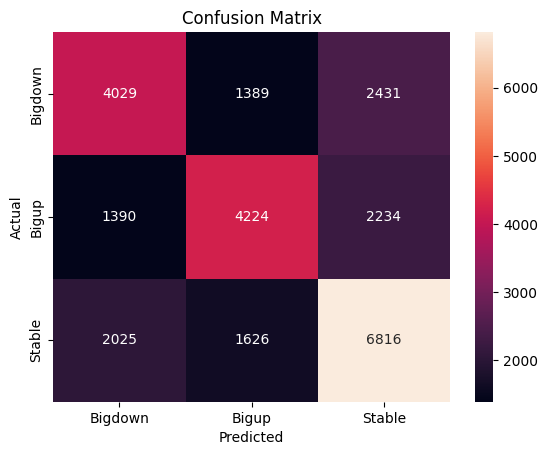

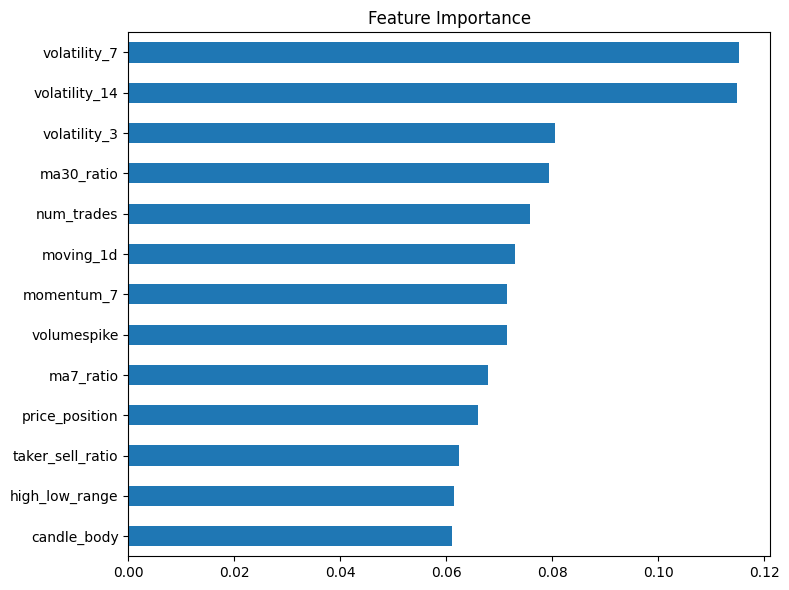

In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder





drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score','taker_buy_ratio','taker_buy_ratio', 'negative_momentum',
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['label']


model = RandomForestClassifier(
    n_estimators=700,
    max_depth=13,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    criterion='entropy',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

model.fit(X_train, y_train)






test_preds = model.predict(X_test)
print("\n--- Test Results ---")
print(classification_report(y_test, test_preds, target_names=['Bigdown', 'Bigup','Stable']))


cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Bigdown', 'Bigup','Stable'],
                                     yticklabels=['Bigdown', 'Bigup','Stable'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [16]:

# Check train performance too
train_preds = model.predict(X_train)
print("--- Train Results ---")
print(classification_report(y_train, train_preds, target_names=['Bigdown', 'Bigup','Stable']))

print("--- Test Results ---")
print(classification_report(y_test, test_preds, target_names=['Bigdown', 'Bigup','Stable']))

--- Train Results ---
              precision    recall  f1-score   support

     Bigdown       0.76      0.70      0.73     15770
       Bigup       0.74      0.71      0.72     15771
      Stable       0.67      0.73      0.70     21039

    accuracy                           0.71     52580
   macro avg       0.72      0.71      0.72     52580
weighted avg       0.72      0.71      0.71     52580

--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.54      0.51      0.53      7849
       Bigup       0.58      0.54      0.56      7848
      Stable       0.59      0.65      0.62     10467

    accuracy                           0.58     26164
   macro avg       0.57      0.57      0.57     26164
weighted avg       0.57      0.58      0.57     26164



In [17]:
print(y_train.unique())
print(sorted(y_train.unique()))

['Bigup' 'Stable' 'Bigdown']
['Bigdown', 'Bigup', 'Stable']


In [19]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score','taker_buy_ratio','taker_buy_ratio', 'negative_momentum',
]

X = df.drop(columns=drop_cols)
y = df['label']

groups = df['type']

logo = LeaveOneGroupOut()

results = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    test_coin = groups.iloc[test_idx].unique()[0]

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=13,
        min_samples_split=5,
        min_samples_leaf=3,
        criterion='entropy',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro')
    weighted_f1 = f1_score(y_test, preds, average='weighted')

    results.append({
        'test_coin': test_coin,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    })

    print(f"\n===== Fold {fold} | Test coin: {test_coin} =====")
    print(classification_report(y_test, preds))


===== Fold 1 | Test coin: ADA =====
              precision    recall  f1-score   support

     Bigdown       0.74      0.69      0.72      3681
       Bigup       0.70      0.74      0.72      3682
      Stable       0.68      0.69      0.68      4924

    accuracy                           0.70     12287
   macro avg       0.71      0.71      0.71     12287
weighted avg       0.71      0.70      0.70     12287


===== Fold 2 | Test coin: AVAX =====
              precision    recall  f1-score   support

     Bigdown       0.74      0.69      0.71      3681
       Bigup       0.71      0.74      0.72      3682
      Stable       0.68      0.69      0.69      4924

    accuracy                           0.71     12287
   macro avg       0.71      0.71      0.71     12287
weighted avg       0.71      0.71      0.71     12287


===== Fold 3 | Test coin: BNB =====
              precision    recall  f1-score   support

     Bigdown       0.42      0.21      0.28      4164
       Bigup     

In [20]:
results_df = pd.DataFrame(results)

print(results_df)

print("\nAverage Results:")
print(results_df[['accuracy', 'macro_f1', 'weighted_f1']].mean())

  test_coin  accuracy  macro_f1  weighted_f1
0       ADA  0.704240  0.706579     0.704301
1      AVAX  0.706356  0.708339     0.706343
2       BNB  0.467536  0.407956     0.427639
3      DOGE  0.404554  0.394050     0.404250
4       ETH  0.433451  0.423097     0.432006
5       SOL  0.396443  0.396132     0.396447

Average Results:
accuracy       0.518764
macro_f1       0.506025
weighted_f1    0.511831
dtype: float64
